In [2]:
import pandas as pd

df = pd.read_csv('Dataset_Reviews+Categories_US.csv')
df

,country_code,art_id,rating,title,text,lang_code,inserted_on,TYPE_NAME_ENGLISH,GLOBAL_ID,PRODUCT_AREA
0,us,70518061,5,Chair,Good product,en,2023-12-15 09:02:29,Chair,"art,70518061",Upholstered chairs
1,us,10405364,5,Light,It is fine! Does what I need it to do,en,2024-01-23 11:45:14,Lamp shade,"art,10405364","Shades, bases and cord set"
2,us,50347131,2,Not worth the price,"Relatively expensive, could do better at the l...",en,2023-09-22 18:04:25,Hook,"art,50347131",Hooks
3,us,39240645,1,Collapsed after 6 weeks,Used this bed for just 6 weeks before the chea...,en,2023-09-10 15:04:01,Bed frame,"spr,39240645",Bed frames and beds with non upholstered headb...
4,us,50478382,5,Really great,"Very crispy, lots of dried berries, a great to...",en,2024-02-12 18:04:37,Granola,"art,50478382",Bread & dairy
...,...,...,...,...,...,...,...,...,...,...
194933,us,426079,5,Looks way more expensive than,Looks way more expensive than it is,en,2022-11-18 21:11:31,Door,"art,00426079","Kitchen fronts, coverpanels, plinths and deco ..."
194934,us,90328135,5,Love the warm look!,I renovated my kitchen and used a mix of high ...,en,2022-11-18 21:11:31,Drawer front,"art,90328135","Kitchen fronts, coverpanels, plinths and deco ..."
194935,us,60348385,5,Lovely,"It has a clean, fresh look. I feel good about ...",en,2022-11-18 21:12:47,Drawer front,"art,60348385","Kitchen fronts, coverpanels, plinths and deco ..."
194936,us,60515402,5,Good value.,Good value.,en,2022-11-18 21:12:47,Door,"art,60515402","Kitchen fronts, coverpanels, plinths and deco ..."


In [3]:
# Preprocessing

df = df.drop_duplicates()
import re

# Assuming df is your DataFrame and it has 'title' and 'text' columns

# Regex pattern for matching emojis
emoji_pattern = re.compile("[" 
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F700-\U0001F77F"  # alchemical symbols
                           u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
                           u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
                           u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                           u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                           u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                           u"\U00002702-\U000027B0"  # Dingbats
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)

def is_only_emojis(text):
    if pd.isna(text):
        text = ''
    text_without_emojis = emoji_pattern.sub(r'', text)
    return text_without_emojis.strip() == ''

# Apply the function to each 'text' and 'title' in the DataFrame
df['text_is_only_emojis'] = df['text'].apply(is_only_emojis)
df['title_is_only_emojis'] = df['title'].apply(is_only_emojis)

# Apply conditions for selection:
# 1. Both title and text are only emojis
# 2. Title is empty and text is only emojis
df['select_condition'] = ((df['title_is_only_emojis'] & df['text_is_only_emojis']) | 
                          (df['title'].isna() | df['title'].str.strip().eq('')) & df['text_is_only_emojis'])

# Count total reviews and those with only emojis
total_reviews = df.shape[0]
only_emojis_count = df['select_condition'].sum()
percentage_only_emojis = (only_emojis_count / total_reviews) * 100
print(f"Total reviews: {total_reviews}")
print(f"Reviews composed only of emojis: {only_emojis_count}")
print(f"Percentage of reviews with only emojis: {percentage_only_emojis:.2f}%\n")

# Filter the DataFrame based on the select_condition
filtered_df_emoji = df[df['select_condition']]
df = df[~df['select_condition']]
df = df.drop(['text_is_only_emojis', 'title_is_only_emojis', 'select_condition'], axis=1)
df

/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_94741/491495156.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text_is_only_emojis'] = df['text'].apply(is_only_emojis)


Total reviews: 194878
Reviews composed only of emojis: 284
Percentage of reviews with only emojis: 0.15%



/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_94741/491495156.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['title_is_only_emojis'] = df['title'].apply(is_only_emojis)
/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_94741/491495156.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['select_condition'] = ((df['title_is_only_emojis'] & df['text_is_only_emojis']) |


,country_code,art_id,rating,title,text,lang_code,inserted_on,TYPE_NAME_ENGLISH,GLOBAL_ID,PRODUCT_AREA
0,us,70518061,5,Chair,Good product,en,2023-12-15 09:02:29,Chair,"art,70518061",Upholstered chairs
1,us,10405364,5,Light,It is fine! Does what I need it to do,en,2024-01-23 11:45:14,Lamp shade,"art,10405364","Shades, bases and cord set"
2,us,50347131,2,Not worth the price,"Relatively expensive, could do better at the l...",en,2023-09-22 18:04:25,Hook,"art,50347131",Hooks
3,us,39240645,1,Collapsed after 6 weeks,Used this bed for just 6 weeks before the chea...,en,2023-09-10 15:04:01,Bed frame,"spr,39240645",Bed frames and beds with non upholstered headb...
4,us,50478382,5,Really great,"Very crispy, lots of dried berries, a great to...",en,2024-02-12 18:04:37,Granola,"art,50478382",Bread & dairy
...,...,...,...,...,...,...,...,...,...,...
194933,us,426079,5,Looks way more expensive than,Looks way more expensive than it is,en,2022-11-18 21:11:31,Door,"art,00426079","Kitchen fronts, coverpanels, plinths and deco ..."
194934,us,90328135,5,Love the warm look!,I renovated my kitchen and used a mix of high ...,en,2022-11-18 21:11:31,Drawer front,"art,90328135","Kitchen fronts, coverpanels, plinths and deco ..."
194935,us,60348385,5,Lovely,"It has a clean, fresh look. I feel good about ...",en,2022-11-18 21:12:47,Drawer front,"art,60348385","Kitchen fronts, coverpanels, plinths and deco ..."
194936,us,60515402,5,Good value.,Good value.,en,2022-11-18 21:12:47,Door,"art,60515402","Kitchen fronts, coverpanels, plinths and deco ..."


In [5]:
df_article = df[df['TYPE_NAME_ENGLISH'] == 'Shelving unit']
df_article

,country_code,art_id,rating,title,text,lang_code,inserted_on,TYPE_NAME_ENGLISH,GLOBAL_ID,PRODUCT_AREA
179,us,30428326,1,Ikea should pay YOU for this POS - it's litera...,I consider myself a reasonably competent Ikea ...,en,2023-04-04 21:04:30,Shelving unit,"art,30428326",Outdoor approved storage
253,us,20488504,5,Great shelves,"Good quality, price and easy to assemble.",en,2022-11-23 15:03:30,Shelving unit,"art,20488504",Outdoor approved storage
465,us,20488504,5,Perfect for our Space,We needed a tall slim tower to put in our bath...,en,2022-12-13 03:04:33,Shelving unit,"art,20488504",Outdoor approved storage
611,us,30428326,1,"Very difficult to put together,","Very difficult to put together, parts provided...",en,2023-04-04 21:04:30,Shelving unit,"art,30428326",Outdoor approved storage
749,us,20488504,5,PLEASANTLY SURPRISED,I was pleasantly surprised for easy assembly a...,en,2023-07-28 06:04:54,Shelving unit,"art,20488504",Outdoor approved storage
...,...,...,...,...,...,...,...,...,...,...
157440,us,30217654,5,Bathroom rack,Love this in every way! The white stain and st...,en,2022-11-18 21:11:46,Shelving unit,"art,30217654",Bathroom small furniture
157442,us,90344456,5,Great shelf!,Fit PERFECTLY in the spot I needed it to. Grea...,en,2022-11-18 21:11:46,Shelving unit,"art,90344456",Bathroom small furniture
157449,us,80549420,1,"defective, returned",unfortunately had to return this unit due to o...,en,2024-01-23 11:45:14,Shelving unit,"art,80549420",Bathroom small furniture
157452,us,30217654,5,Great,Great,en,2022-11-18 21:11:31,Shelving unit,"art,30217654",Bathroom small furniture


In [6]:
df_area = df[df['PRODUCT_AREA'] == 'Open storage']
df_area

,country_code,art_id,rating,title,text,lang_code,inserted_on,TYPE_NAME_ENGLISH,GLOBAL_ID,PRODUCT_AREA
78594,us,70332124,1,Beware,Doesn't come with mounting brackets and didn't...,en,2024-02-08 09:04:45,Cabinet,"art,70332124",Open storage
78595,us,10275862,1,Dowels/holes not a proper fit,We were very disappointed in this after easy a...,en,2023-06-04 09:04:15,Shelving unit,"art,10275862",Open storage
78596,us,20275885,5,Kallax 2x4 review,Great bookshelf! Fit a bunch of old text books...,en,2023-01-13 18:04:17,Shelving unit,"art,20275885",Open storage
78597,us,415599,5,Highly recommended!,The Kallax system has been a life saver. I’m a...,en,2023-03-16 21:04:01,Shelf unit,"art,00415599",Open storage
78598,us,20473593,5,Perfect stand for 2 printers,I needed a stand to hold both printers in a li...,en,2023-12-06 06:00:37,Shelf unit,"art,20473593",Open storage
...,...,...,...,...,...,...,...,...,...,...
86580,us,80275887,5,Great product!,Great product!,en,2022-11-18 21:12:47,Shelving unit,"art,80275887",Open storage
86581,us,90286649,5,A little small,A little small but does the job. Keeps a clean...,en,2022-11-18 21:12:47,Insert with 2 drawers,"art,90286649",Open storage
86582,us,20275814,5,Multi purpose shelving,Perfect for my sewing room project!,en,2022-11-18 21:12:47,Shelving unit,"art,20275814",Open storage
86583,us,20275814,5,Great small bookcase,Perfect for what I needed and fairly easy to a...,en,2022-11-18 21:12:47,Shelving unit,"art,20275814",Open storage


/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_94741/2638014406.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df_area, palette='viridis')


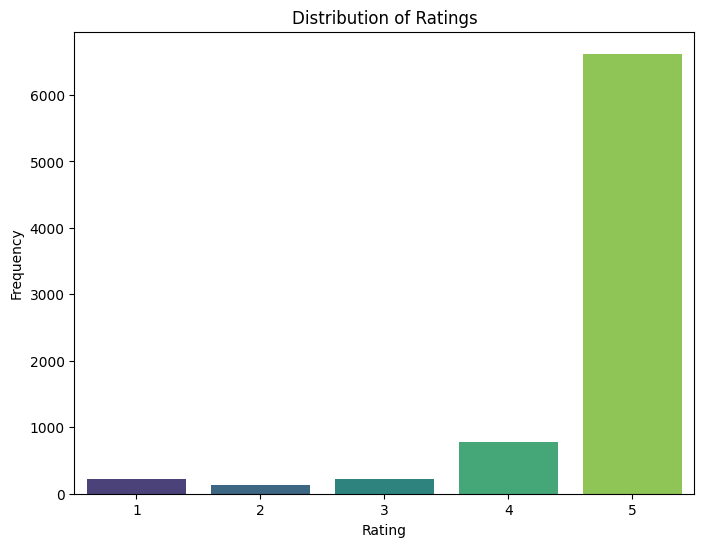

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Distribution Plot
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=df_area, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [8]:
sampled_df = df_area.sample(n=200)
sampled_df

,country_code,art_id,rating,title,text,lang_code,inserted_on,TYPE_NAME_ENGLISH,GLOBAL_ID,PRODUCT_AREA
85207,us,30275861,5,Love it,Easy to put together!!,en,2023-04-17 09:04:50,Shelving unit,"art,30275861",Open storage
80585,us,275848,5,Easy to assemble,Bought two of these to hang on the wall. Easy ...,en,2022-11-18 21:12:47,Shelf unit,"art,00275848",Open storage
84101,us,90286649,4,Good,It's a fine product and does what it advertise...,en,2022-11-18 21:05:59,Insert with 2 drawers,"art,90286649",Open storage
81141,us,80275887,5,Great Price,Great price and quality. Perfect for my craft ...,en,2022-11-21 15:05:50,Shelving unit,"art,80275887",Open storage
83878,us,79278269,4,Always versatile,I bought this along with the 2x2 and the 3x4 K...,en,2022-11-18 21:09:22,Shelving unit with doors,"spr,79278269",Open storage
...,...,...,...,...,...,...,...,...,...,...
85467,us,80401292,5,Easy instillation,Bought this to organize our wine. It is easy t...,en,2022-11-18 21:11:17,Insert for bottles,"art,80401292",Open storage
85581,us,20278167,5,Organizers,These drawers and doors hide all my craft supp...,en,2022-11-18 21:09:34,Insert with door,"art,20278167",Open storage
84113,us,59278307,5,Great set up for Laundry/catch all room,I have bought cube storage from other stores b...,en,2022-11-18 21:05:59,Shelf unit with 4 inserts,"spr,59278307",Open storage
86046,us,10409932,5,Love decluttering!,We wanted to get rid of the clutter of numerou...,en,2022-11-18 21:05:59,Shelving unit,"art,10409932",Open storage


/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_94741/2054588984.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=sampled_df, palette='viridis')


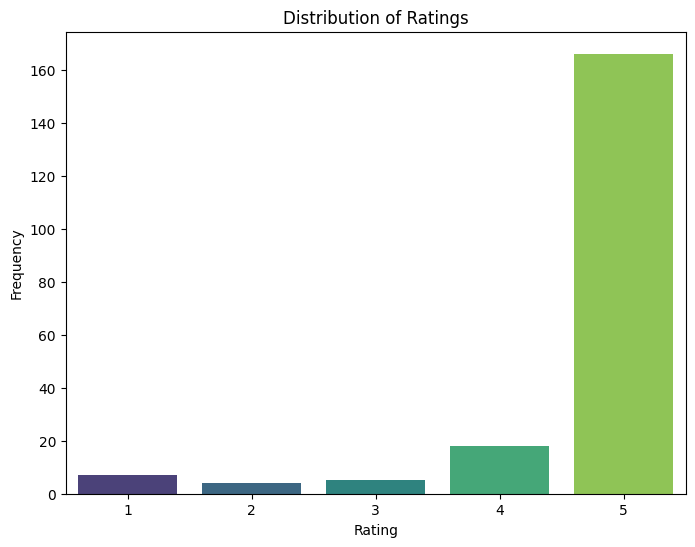

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Distribution Plot
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=sampled_df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()